# 3. Univariate

Continues from [0_load_and_orient.ipynb](0_load_and_orient.ipynb) — reloads
the same setup so this notebook runs standalone.

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
# load csv data for both train and test
df_train = pd.read_csv("../../data/train.csv")
df_test = pd.read_csv("../../data/test.csv")

In [59]:
# Feature type categorization, from data_description.txt
# each list is sorted() so the final order is alphabetical regardless of
# how the source below groups them (kept grouped here for readability)

IDENTIFIER = ["Id"]
TARGET = ["SalePrice"]

NUMERIC_COLS = sorted([
    "LotFrontage", "LotArea", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2",
    "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "LowQualFinSF",
    "GrLivArea", "BsmtFullBath", "BsmtHalfBath", "FullBath", "HalfBath",
    "BedroomAbvGr", "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces",
    "GarageCars", "GarageArea", "WoodDeckSF", "OpenPorchSF",
    "EnclosedPorch", "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal",
    # temporal — usually engineered into ages/deltas rather than used raw
    "YearBuilt", "YearRemodAdd", "GarageYrBlt", "MoSold", "YrSold",
])

# has a genuine order -> integer-encode in that order, don't one-hot
ORDINAL_COLS = sorted([
    "OverallQual", "OverallCond", "LotShape", "LandSlope",
    "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "BsmtExposure",
    "BsmtFinType1", "BsmtFinType2", "HeatingQC", "KitchenQual",
    "Functional", "FireplaceQu", "GarageFinish", "GarageQual",
    "GarageCond", "PavedDrive", "PoolQC", "Utilities",
])

# no inherent order -> one-hot/dummy encode
NOMINAL_COLS = sorted([
    "MSSubClass",  # gotcha: stored as int, but it's a dwelling-type code
    "MSZoning", "Street", "Alley", "LandContour", "LotConfig",
    "Neighborhood", "Condition1", "Condition2", "BldgType", "HouseStyle",
    "RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd", "MasVnrType",
    "Foundation", "Heating", "CentralAir", "Electrical", "GarageType",
    "MiscFeature", "SaleType", "SaleCondition", "Fence",
])

all_cols = NUMERIC_COLS + ORDINAL_COLS + NOMINAL_COLS
expected = set(df_train.columns) - set(IDENTIFIER) - set(TARGET)
assert set(all_cols) == expected, set(all_cols) ^ expected
assert len(all_cols) == len(expected)  # no duplicates
len(NUMERIC_COLS), len(ORDINAL_COLS), len(NOMINAL_COLS)

(33, 21, 25)

## Numeric features

Distribution shape for each of the 33 `NUMERIC_COLS`: histograms, spread,
skew/kurtosis, zero-heavy columns. Temporal columns (`YearBuilt`,
`YearRemodAdd`, `GarageYrBlt`, `MoSold`, `YrSold`) are counts/timelines
rather than continuous shapes, so they get their own treatment below.

**Scope:** flag skewed/zero-heavy features as transform candidates —
don't transform here, that's preprocessing.

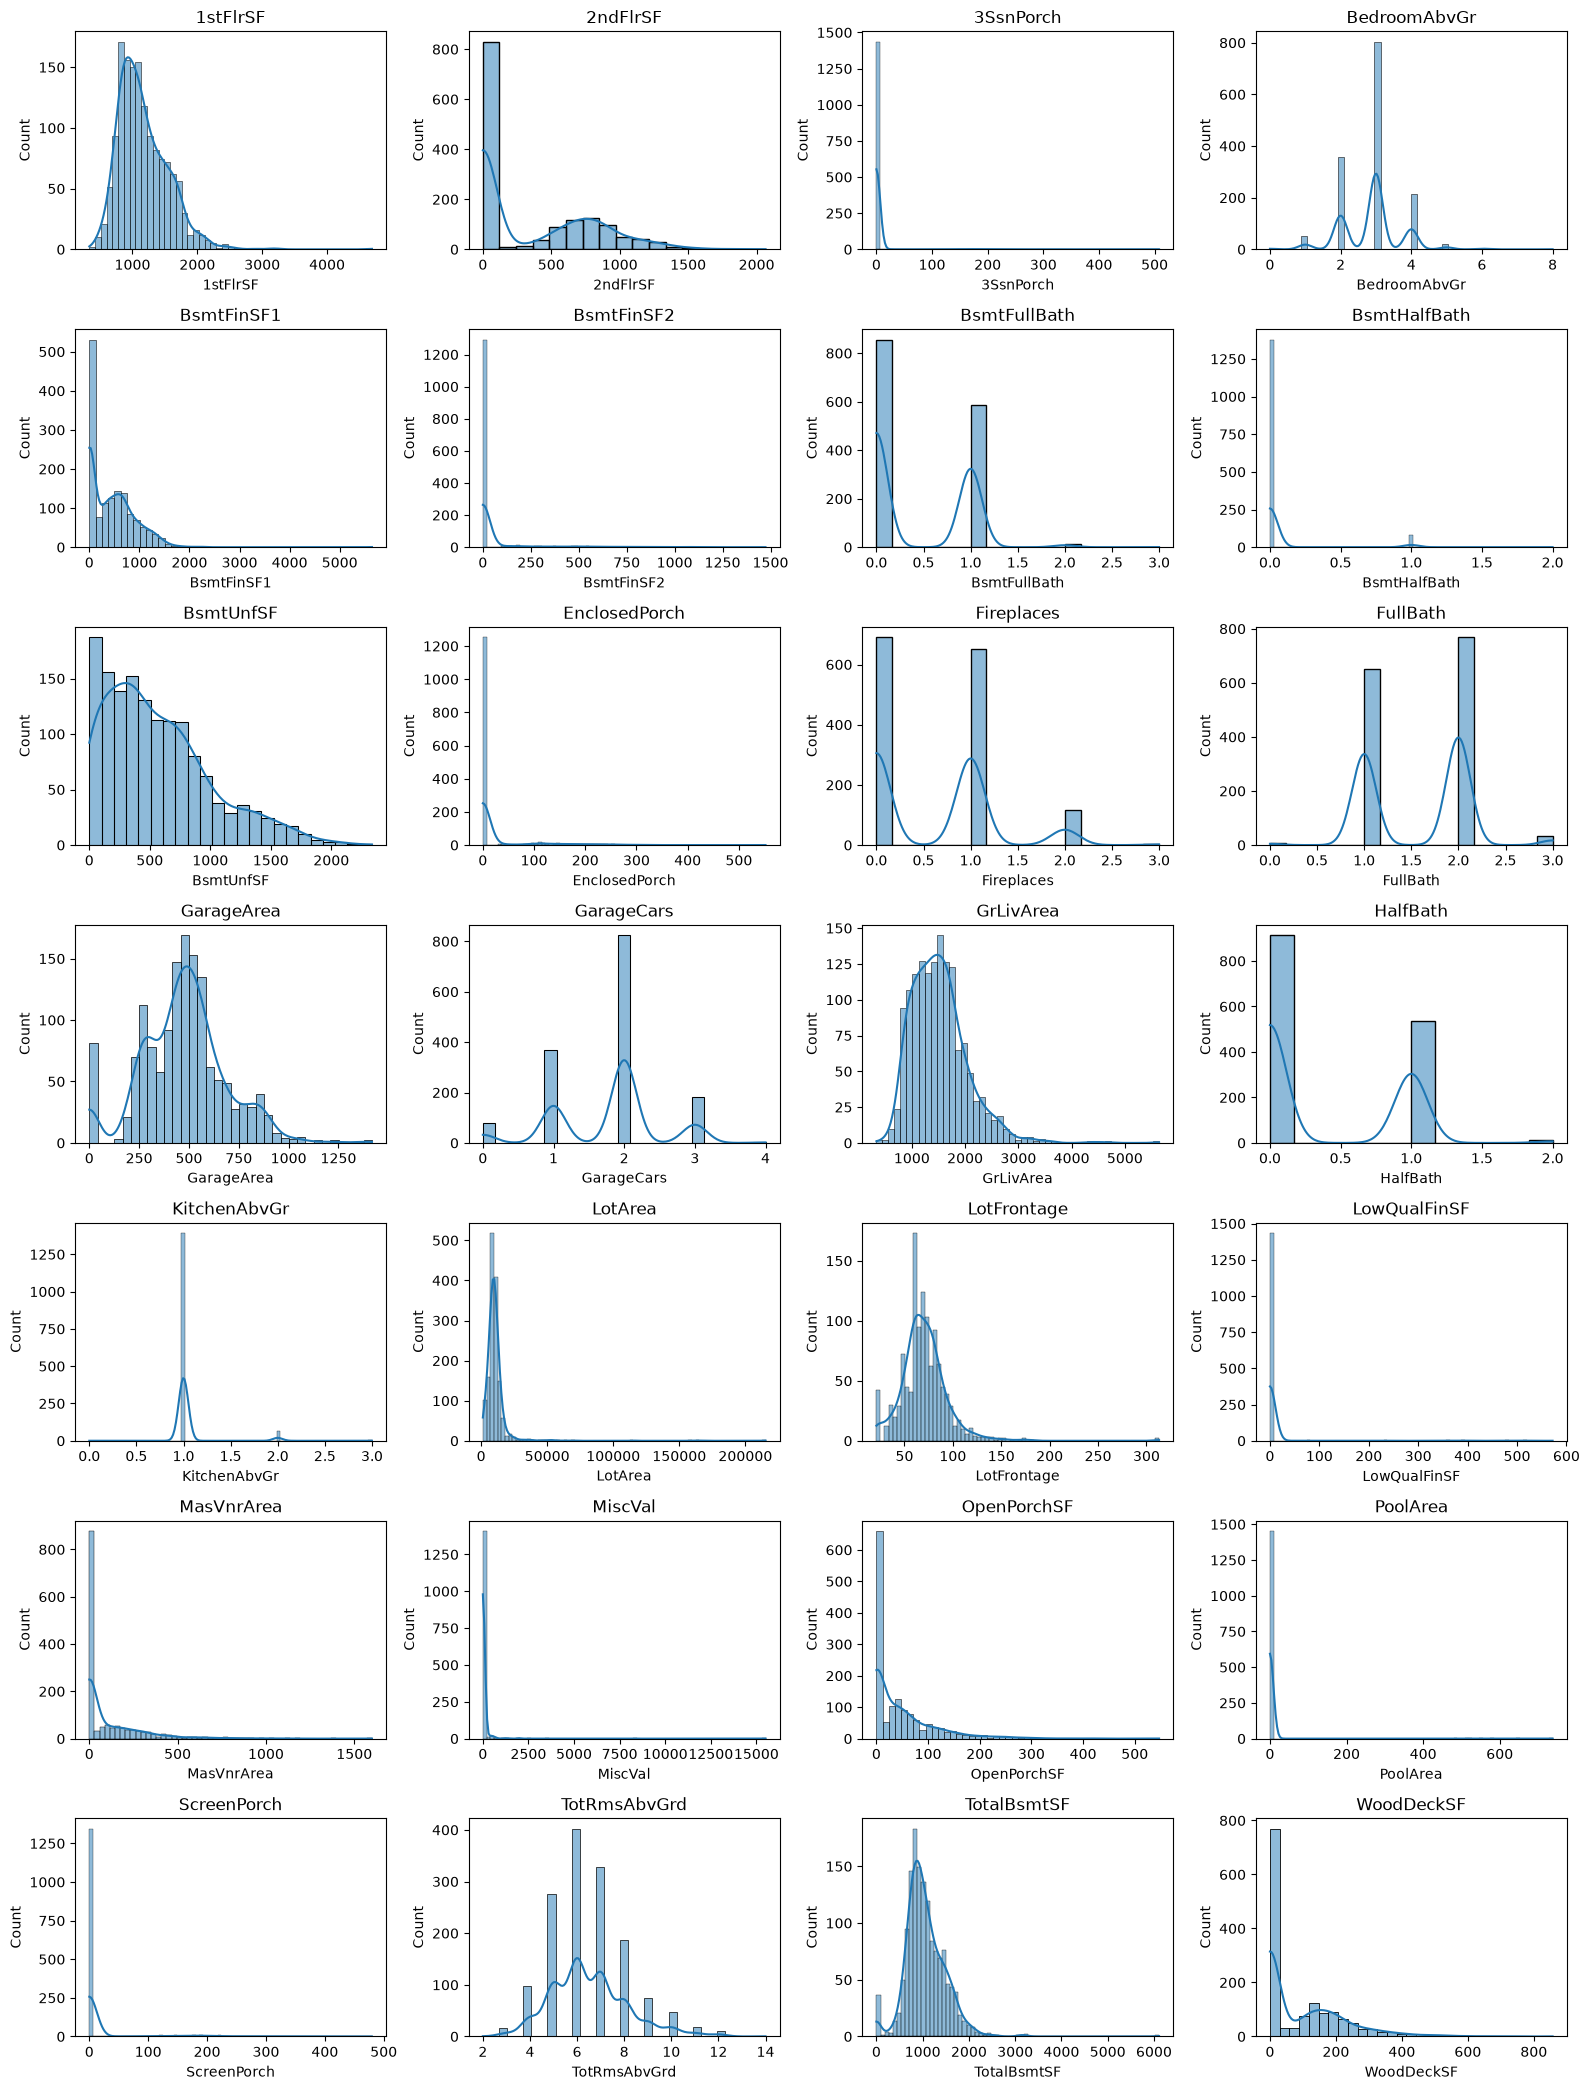

In [60]:
TEMPORAL_COLS = ["YearBuilt", "YearRemodAdd", "GarageYrBlt", "MoSold", "YrSold"]
CONTINUOUS_NUMERIC_COLS = [c for c in NUMERIC_COLS if c not in TEMPORAL_COLS]

# distribution shape: grid of histograms + KDE
n_cols = 4
n_rows = -(-len(CONTINUOUS_NUMERIC_COLS) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
for ax, col in zip(axes.flat, CONTINUOUS_NUMERIC_COLS):
    sns.histplot(x= df_train[col], kde=True, ax=ax)
    ax.set_title(col)
for ax in axes.flat[len(CONTINUOUS_NUMERIC_COLS):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

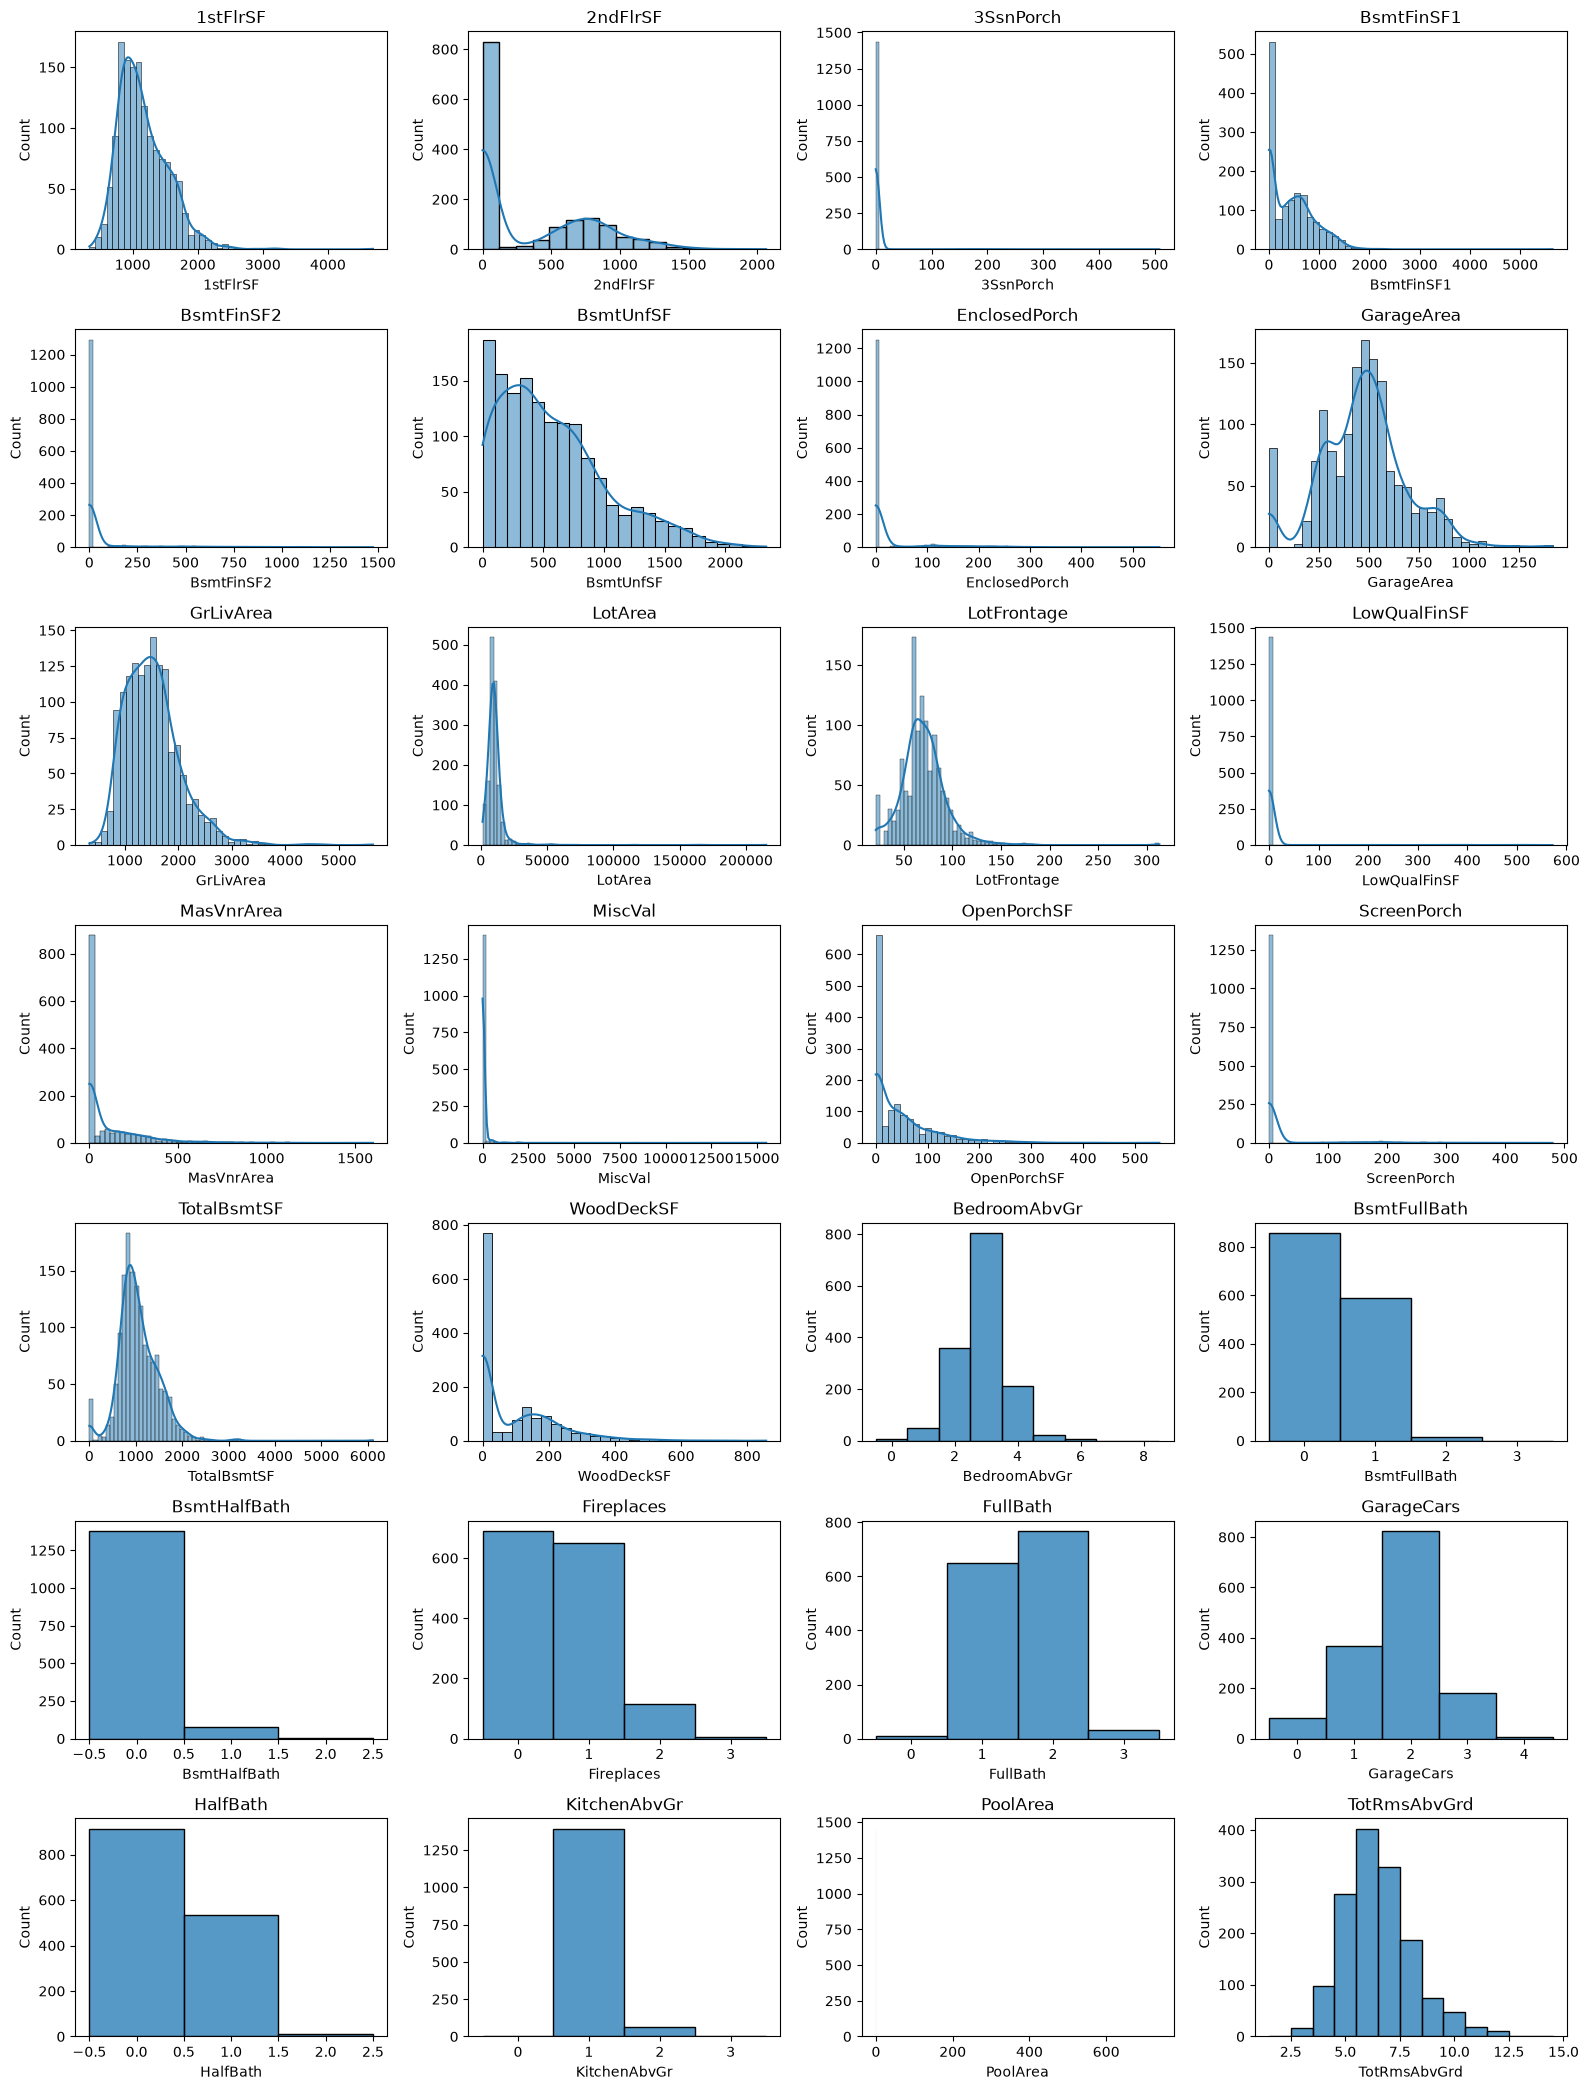

In [61]:
# Split the columns by cardinality first, then let that drive both the kde flag and the plot type
DISCRETE_THRESHOLD = 15

nunique = df_train[CONTINUOUS_NUMERIC_COLS].nunique()
discrete = nunique[nunique <= DISCRETE_THRESHOLD].index.tolist()
continuous = nunique[nunique > DISCRETE_THRESHOLD].index.tolist()

plot_cols = continuous + discrete  # continuous first, so the grid reads cleanly

n_cols = 4
n_rows = -(-len(plot_cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))

for ax, col in zip(axes.flat, plot_cols):
    is_continuous = col in continuous
    sns.histplot(
        data=df_train,
        x=col,
        kde=is_continuous,
        discrete=not is_continuous,
        ax=ax,
    )
    ax.set_title(col)

for ax in axes.flat[len(plot_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [62]:
# summary stats: spread + shape + zero-heaviness
summary_rows = []
for col in CONTINUOUS_NUMERIC_COLS:
    s = df_train[col]
    summary_rows.append({
        "column": col,
        "mean": s.mean(),
        "median": s.median(),
        "std": s.std(),
        "min": s.min(),
        "max": s.max(),
        "skew": s.skew(),
        "kurtosis": s.kurt(),
        "pct_zero": (s == 0).mean(),
    })
numeric_summary = pd.DataFrame(summary_rows).set_index("column")
numeric_summary

,mean,median,std,min,max,skew,kurtosis,pct_zero
column,,,,,,,,
1stFlrSF,1162.626712,1087.0,386.587738,334.0,4692.0,1.376757,5.745841,0.000000
2ndFlrSF,346.992466,0.0,436.528436,0.0,2065.0,0.813030,-0.553464,0.567808
3SsnPorch,3.409589,0.0,29.317331,0.0,508.0,10.304342,123.662379,0.983562
BedroomAbvGr,2.866438,3.0,0.815778,0.0,8.0,0.211790,2.230875,0.004110
BsmtFinSF1,443.639726,383.5,456.098091,0.0,5644.0,1.685503,11.118236,0.319863
BsmtFinSF2,46.549315,0.0,161.319273,0.0,1474.0,4.255261,20.113338,0.885616
BsmtFullBath,0.425342,0.0,0.518911,0.0,3.0,0.596067,-0.839098,0.586301
BsmtHalfBath,0.057534,0.0,0.238753,0.0,2.0,4.103403,16.396642,0.943836
BsmtUnfSF,567.240411,477.5,441.866955,0.0,2336.0,0.920268,0.474994,0.080822


In [63]:
summary = pd.DataFrame({
    "zero_frac": (df_train[CONTINUOUS_NUMERIC_COLS] == 0).mean(),
    "skew": df_train[CONTINUOUS_NUMERIC_COLS].skew(),
    "nunique": df_train[CONTINUOUS_NUMERIC_COLS].nunique(),
    "top_frac": df_train[CONTINUOUS_NUMERIC_COLS].apply(
        lambda s: s.value_counts(normalize=True).iloc[0]
    ),
}).sort_values("zero_frac", ascending=False)
summary

,zero_frac,skew,nunique,top_frac
PoolArea,0.995205,14.828374,8,0.995205
3SsnPorch,0.983562,10.304342,20,0.983562
LowQualFinSF,0.982192,9.011341,24,0.982192
MiscVal,0.964384,24.476794,21,0.964384
BsmtHalfBath,0.943836,4.103403,3,0.943836
ScreenPorch,0.920548,4.122214,76,0.920548
BsmtFinSF2,0.885616,4.255261,144,0.885616
EnclosedPorch,0.857534,3.089872,120,0.857534
HalfBath,0.625342,0.675897,3,0.625342
MasVnrArea,0.589726,2.669084,327,0.592975


In [64]:
# flag candidates — informational only, no transforming here
skewed = numeric_summary[numeric_summary["skew"].abs() > 1].sort_values("skew", ascending=False)
zero_heavy = numeric_summary[numeric_summary["pct_zero"] > 0.5].sort_values("pct_zero", ascending=False)
print(f"{len(skewed)} skewed columns (|skew| > 1):")
display(skewed[["skew", "kurtosis"]])
print(f"\n{len(zero_heavy)} zero-heavy columns (>50% zero):")
display(zero_heavy[["pct_zero", "skew"]])

18 skewed columns (|skew| > 1):


,skew,kurtosis
column,,
MiscVal,24.476794,701.003342
PoolArea,14.828374,223.268499
LotArea,12.207688,203.243271
3SsnPorch,10.304342,123.662379
LowQualFinSF,9.011341,83.234817
KitchenAbvGr,4.488397,21.532404
BsmtFinSF2,4.255261,20.113338
ScreenPorch,4.122214,18.439068
BsmtHalfBath,4.103403,16.396642



13 zero-heavy columns (>50% zero):


,pct_zero,skew
column,,
PoolArea,0.995205,14.828374
3SsnPorch,0.983562,10.304342
LowQualFinSF,0.982192,9.011341
MiscVal,0.964384,24.476794
BsmtHalfBath,0.943836,4.103403
ScreenPorch,0.920548,4.122214
BsmtFinSF2,0.885616,4.255261
EnclosedPorch,0.857534,3.089872
HalfBath,0.625342,0.675897


### Temporal columns

`YearBuilt`/`YearRemodAdd`/`GarageYrBlt` are year values — histograms show
*when* houses were built/remodeled/garaged, not a shape to call skewed.
`MoSold`/`YrSold` are low-cardinality sale-timing counts — bar charts, not
histograms.

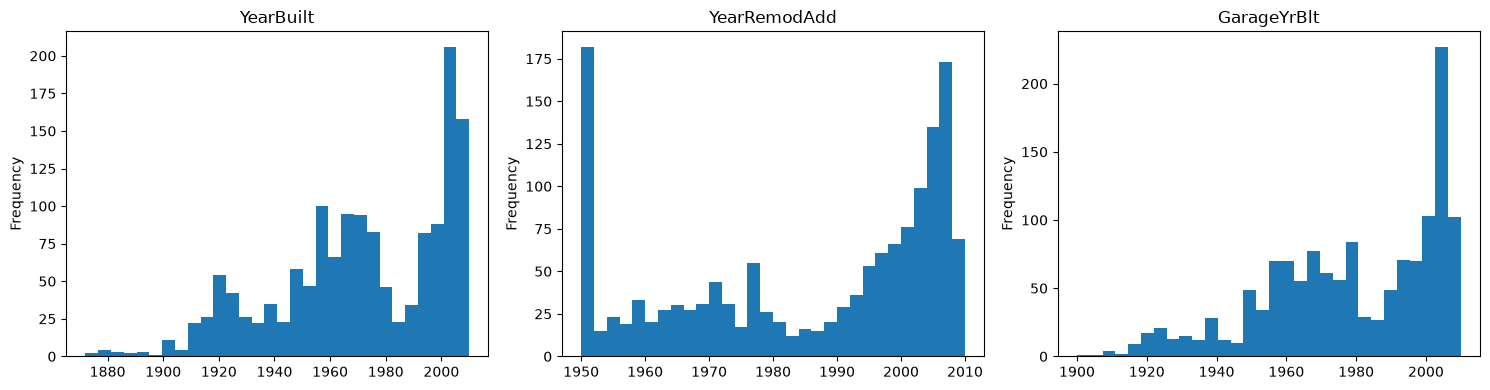

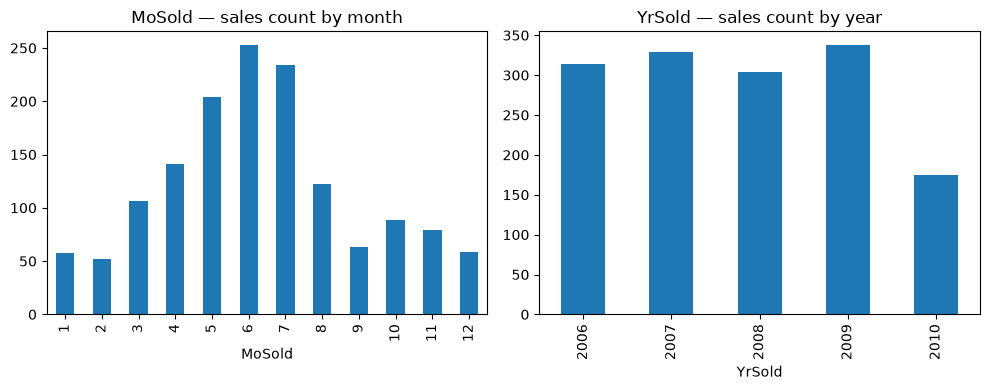

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["YearBuilt", "YearRemodAdd", "GarageYrBlt"]):
    df_train[col].dropna().astype(int).plot(kind="hist", bins=30, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df_train["MoSold"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("MoSold — sales count by month")
df_train["YrSold"].value_counts().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title("YrSold — sales count by year")
plt.tight_layout()
plt.show()

**Decision:**

- 21 of 28 continuous columns (75%) flagged as skewed (18, |skew| > 1) or zero-heavy (13, >50% zero) — heavy overlap between the two lists.
- **Presence/absence group** (`MiscVal`, `PoolArea`, `LotArea`, `3SsnPorch`, `LowQualFinSF`, `KitchenAbvGr`, `BsmtFinSF2`, `ScreenPorch`, `BsmtHalfBath`, `EnclosedPorch`, `MasVnrArea`, `2ndFlrSF`, `HalfBath`, `BsmtFullBath`): driven by an amenity most houses simply don't have, not by outliers within an otherwise-normal population — candidates for a has-X flag plus a transform on the nonzero subset, rather than a plain log.
- **Right-skewed-size group** (`GrLivArea`, `TotalBsmtSF`, `BsmtFinSF1`, `1stFlrSF`, `LotFrontage`, `OpenPorchSF`, `WoodDeckSF`): skew 1.4–2.4, low/no `zero_frac` — the more familiar right-skewed-size story, straightforward log/Box-Cox candidates.
- **Clean, no flag** (7): `BsmtUnfSF`, `FullBath`, `BedroomAbvGr`, `TotRmsAbvGrd`, `Fireplaces`, `GarageCars`, `GarageArea` — roughly symmetric counts/areas.
- **Temporal columns:** expected shapes, not anomalies — `YearBuilt`/`YearRemodAdd`/`GarageYrBlt` skew toward recent decades (consistent with [2_missingness.ipynb](2_missingness.ipynb)'s finding that `GarageYrBlt` is null exactly where there's no garage), `MoSold` peaks in the summer house-buying months, `YrSold` is roughly flat across the 5 sale years.
- **Boundary held:** every flag above is informational — no log/Box-Cox/binary transform applied in this notebook, that's preprocessing's job.


## Ordinal features

Value counts per level for each of the 21 `ORDINAL_COLS`; check observed
levels against the order implied by `data_description.txt`; flag lopsided
levels.

In [66]:
for col in ORDINAL_COLS:
    print(f"--- {col} ---")
    print((df_train[col].value_counts(dropna=False, normalize=True) * 100).round(3))
    print()


--- BsmtCond ---
BsmtCond
TA     89.795
Gd      4.452
Fa      3.082
NaN     2.534
Po      0.137
Name: proportion, dtype: float64

--- BsmtExposure ---
BsmtExposure
No     65.274
Av     15.137
Gd      9.178
Mn      7.808
NaN     2.603
Name: proportion, dtype: float64

--- BsmtFinType1 ---
BsmtFinType1
Unf    29.452
GLQ    28.630
ALQ    15.068
BLQ    10.137
Rec     9.110
LwQ     5.068
NaN     2.534
Name: proportion, dtype: float64

--- BsmtFinType2 ---
BsmtFinType2
Unf    86.027
Rec     3.699
LwQ     3.151
NaN     2.603
BLQ     2.260
ALQ     1.301
GLQ     0.959
Name: proportion, dtype: float64

--- BsmtQual ---
BsmtQual
TA     44.452
Gd     42.329
Ex      8.288
NaN     2.534
Fa      2.397
Name: proportion, dtype: float64

--- ExterCond ---
ExterCond
TA    87.808
Gd    10.000
Fa     1.918
Ex     0.205
Po     0.068
Name: proportion, dtype: float64

--- ExterQual ---
ExterQual
TA    62.055
Gd    33.425
Ex     3.562
Fa     0.959
Name: proportion, dtype: float64

--- FireplaceQu ---
Fireplace

In [67]:
for col in ORDINAL_COLS:
    print(f"--- {col} ---")
    counts = df_train[col].value_counts(dropna=False)
    pcts = df_train[col].value_counts(dropna=False, normalize=True) * 100
    table = pd.DataFrame({"count": counts, "pct": pcts.round(2)})
    print(table)
    print()


--- BsmtCond ---
          count    pct
BsmtCond              
TA         1311  89.79
Gd           65   4.45
Fa           45   3.08
NaN          37   2.53
Po            2   0.14

--- BsmtExposure ---
              count    pct
BsmtExposure              
No              953  65.27
Av              221  15.14
Gd              134   9.18
Mn              114   7.81
NaN              38   2.60

--- BsmtFinType1 ---
              count    pct
BsmtFinType1              
Unf             430  29.45
GLQ             418  28.63
ALQ             220  15.07
BLQ             148  10.14
Rec             133   9.11
LwQ              74   5.07
NaN              37   2.53

--- BsmtFinType2 ---
              count    pct
BsmtFinType2              
Unf            1256  86.03
Rec              54   3.70
LwQ              46   3.15
NaN              38   2.60
BLQ              33   2.26
ALQ              19   1.30
GLQ              14   0.96

--- BsmtQual ---
          count    pct
BsmtQual              
TA          649  

In [68]:
missing_in_train = {
    "OverallCond": [10],
    "ExterQual": ["Po"],
    "BsmtQual": ["Po"],
    "BsmtCond": ["Ex"],
    "KitchenQual": ["Po"],
    "Functional": ["Sal"],
    "PoolQC": ["TA"],
    "Utilities": ["NoSewr", "ELO"],
}

for col, levels in missing_in_train.items():
    hits = df_test[col].isin(levels).sum()
    print(f"{col}: {levels} -> {hits} rows in test")


OverallCond: [10] -> 0 rows in test
ExterQual: ['Po'] -> 0 rows in test
BsmtQual: ['Po'] -> 0 rows in test
BsmtCond: ['Ex'] -> 0 rows in test
KitchenQual: ['Po'] -> 0 rows in test
Functional: ['Sal'] -> 0 rows in test
PoolQC: ['TA'] -> 0 rows in test
Utilities: ['NoSewr', 'ELO'] -> 0 rows in test


In [69]:
# documented level order, worst -> best, per data_description.txt
# (NaN/"NA" left out — countplot excludes it from the bars anyway; already
# covered by the value-counts tables above)
ORDER = {
    "OverallQual": list(range(1, 11)),
    "OverallCond": list(range(1, 11)),
    "LotShape": ["IR3", "IR2", "IR1", "Reg"],
    "LandSlope": ["Sev", "Mod", "Gtl"],
    "ExterQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "ExterCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtExposure": ["No", "Mn", "Av", "Gd"],
    "BsmtFinType1": ["Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFinType2": ["Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "HeatingQC": ["Po", "Fa", "TA", "Gd", "Ex"],
    "KitchenQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Functional": ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "FireplaceQu": ["Po", "Fa", "TA", "Gd", "Ex"],
    "GarageFinish": ["Unf", "RFn", "Fin"],
    "GarageQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "GarageCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "PavedDrive": ["N", "P", "Y"],
    "PoolQC": ["Fa", "TA", "Gd", "Ex"],
    "Utilities": ["ELO", "NoSeWa", "NoSewr", "AllPub"],
}

assert set(ORDER.keys()) == set(ORDINAL_COLS)


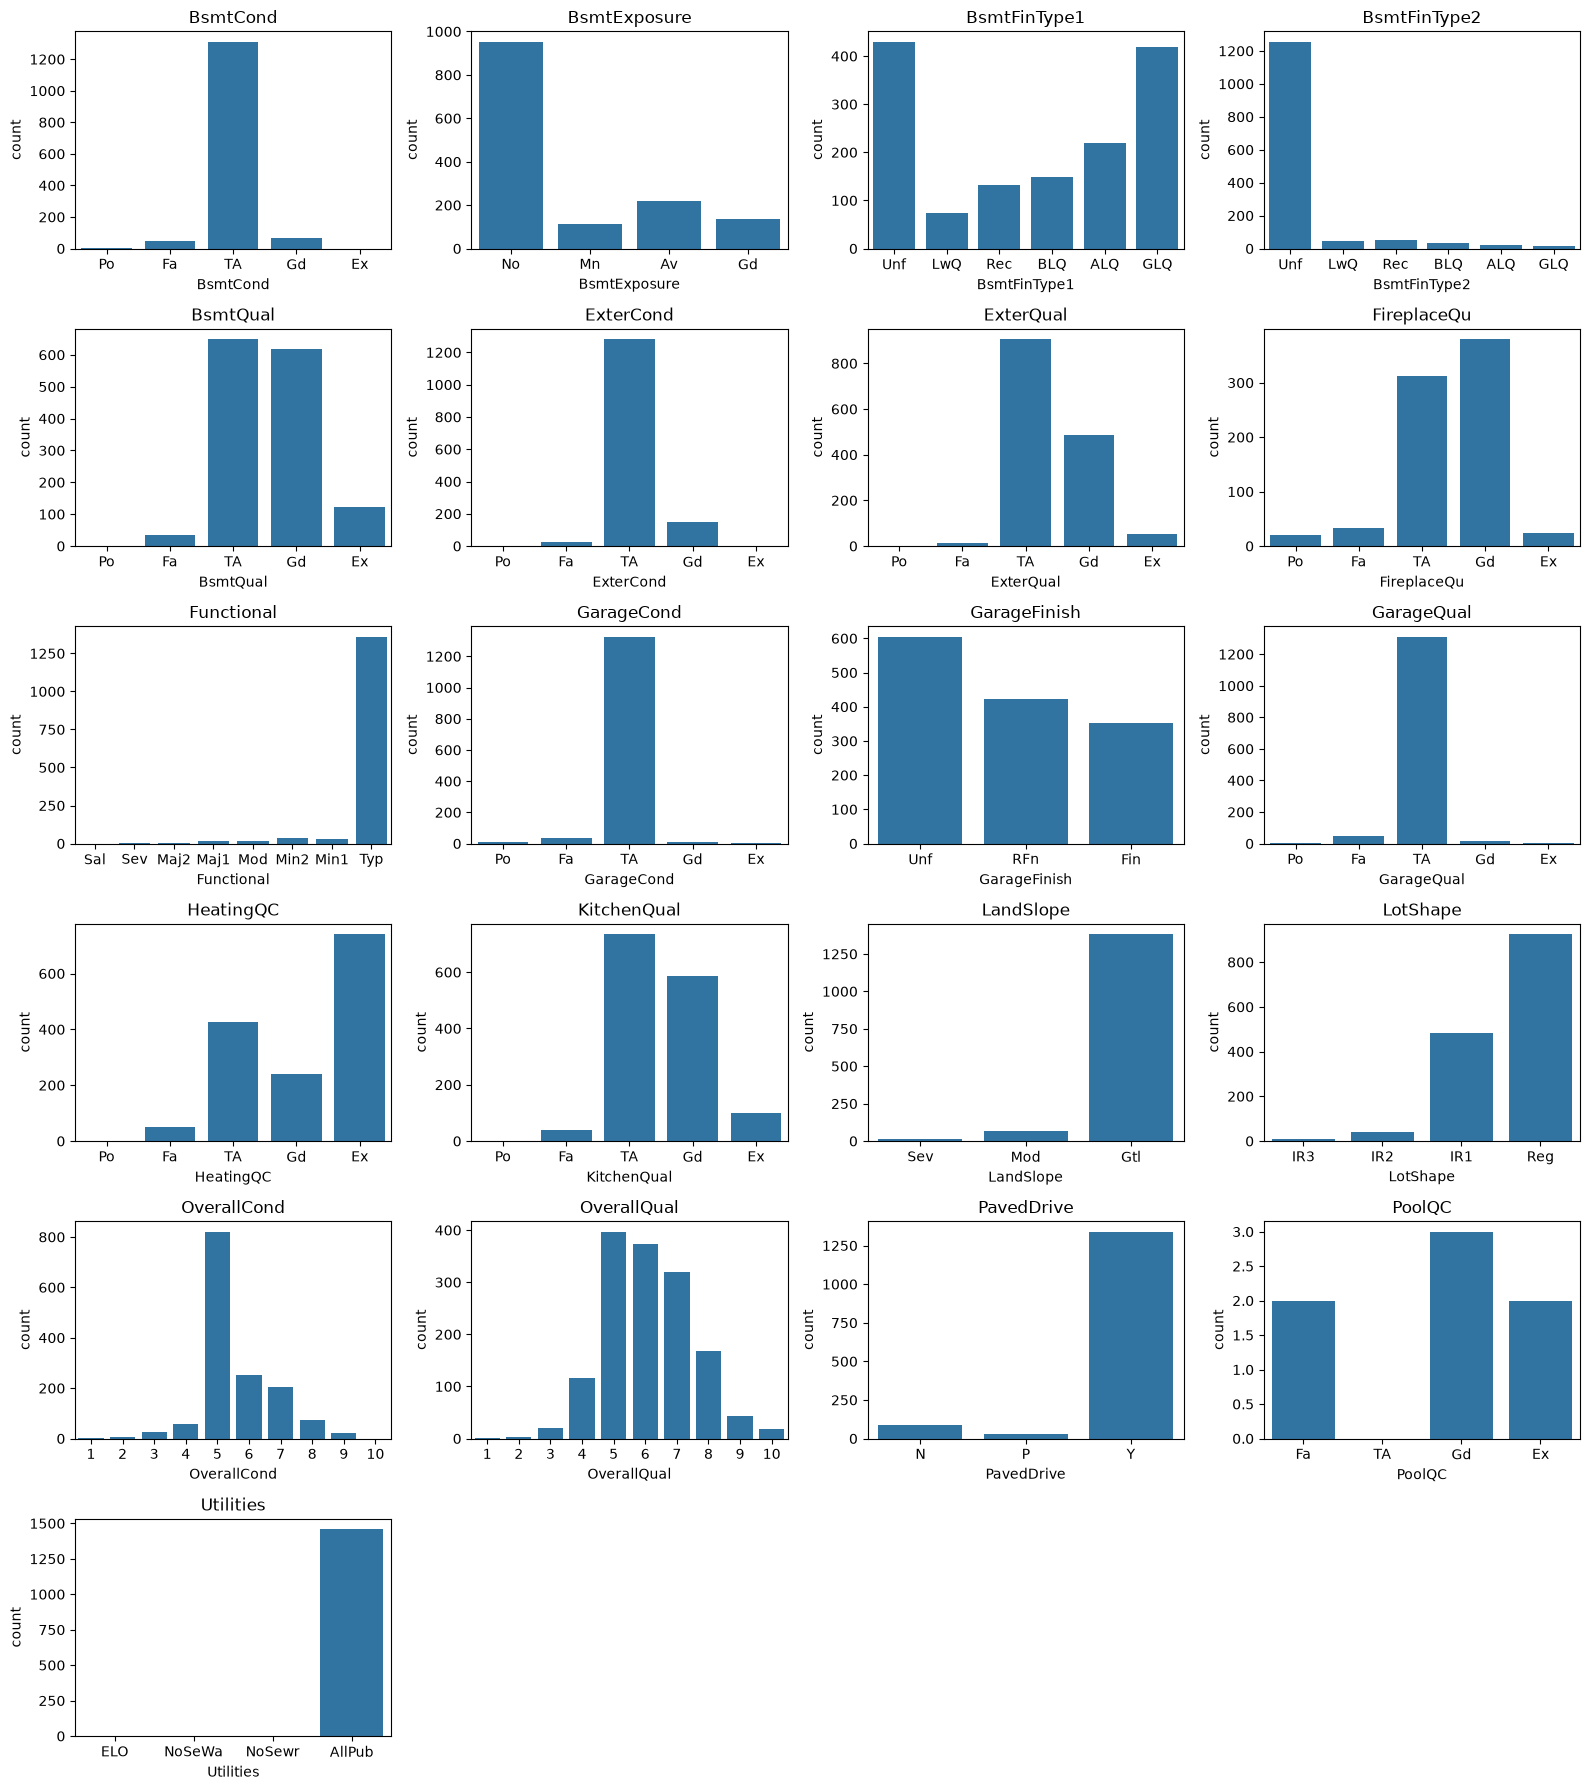

In [70]:
n_cols = 4
n_rows = -(-len(ORDINAL_COLS) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))

for ax, col in zip(axes.flat, ORDINAL_COLS):
    sns.countplot(data=df_train, x=col, order=ORDER[col], ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=0)

for ax in axes.flat[len(ORDINAL_COLS):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


In [71]:
# lopsided levels: smallest observed level per ordinal column, excluding NaN
# (NaN is often a legitimate structural-absence category, already covered
# in 2_missingness.ipynb — this flag is about genuinely rare *observed* levels)
LOPSIDED_THRESHOLD = 0.01

min_level_pct = {
    col: df_train[col].value_counts(normalize=True, dropna=True).min()
    for col in ORDINAL_COLS
}

ordinal_lopsided = (
    pd.DataFrame.from_dict(min_level_pct, orient="index", columns=["min_level_pct"])
    .sort_values("min_level_pct")
)

flagged = ordinal_lopsided[ordinal_lopsided["min_level_pct"] < LOPSIDED_THRESHOLD]
print(f"{len(flagged)} of {len(ORDINAL_COLS)} ordinal columns have a level under {LOPSIDED_THRESHOLD:.0%}:")
flagged


13 of 21 ordinal columns have a level under 1%:


,min_level_pct
ExterCond,0.000685
Functional,0.000685
HeatingQC,0.000685
OverallCond,0.000685
Utilities,0.000685
OverallQual,0.001370
BsmtCond,0.001405
GarageCond,0.001450
GarageQual,0.002175
LotShape,0.006849


**Decision:**

- Value counts, order check, and bar charts confirm the 21 ordinal columns behave as documented — every observed level matches the order in `data_description.txt`, with no order contradictions.
- 8 documented levels never appear in train (`OverallCond` 10, `ExterQual`/`BsmtQual`/`KitchenQual` `Po`, `BsmtCond` `Ex`, `Functional` `Sal`, `PoolQC` `TA`, `Utilities` `NoSewr`/`ELO`) — none of them appear in test either, so these are genuinely rare/absent categories, not a train-only gap.
- NaN percentages match [2_missingness.ipynb](2_missingness.ipynb)'s structural-absence findings exactly (Bsmt ≈2.5%, Garage 5.5%, `FireplaceQu` 47.3%, `PoolQC` 99.5%).
- The lopsided-levels table (1% threshold, NaN excluded) flags 13 of 21 columns:
  - `Utilities` is the standalone case worth carrying forward as a drop-the-whole-column candidate — 99.93% `AllPub`, essentially zero variance regardless of which level is rare.
  - The other 12 (`ExterCond`, `Functional`, `HeatingQC`, `OverallCond`, `OverallQual`, `BsmtCond`, `GarageCond`, `GarageQual`, `LotShape`, `LandSlope`, `ExterQual`, `BsmtFinType2`) are healthy, varying columns with just one thin tail level — candidates for bucketing rare levels together at encoding time, not for dropping the column.
- **Boundary held:** no encoding, merging, or dropping applied here — just flags. Merge/drop decisions belong in preprocessing, informed by how these levels relate to `SalePrice` in the bivariate step still ahead.


## Nominal features

Cardinality and frequency for each of the 25 `NOMINAL_COLS`; flag rare
categories (candidates for grouping later).

In [72]:
# cardinality + dominant-category share per nominal column
nominal_summary = pd.DataFrame({
    "nunique": df_train[NOMINAL_COLS].nunique(),
    "top_category": df_train[NOMINAL_COLS].apply(lambda s: s.value_counts().index[0]),
    "top_frac": df_train[NOMINAL_COLS].apply(lambda s: s.value_counts(normalize=True).iloc[0]),
}).sort_values("nunique", ascending=False)
nominal_summary


,nunique,top_category,top_frac
Neighborhood,25,NAmes,0.154110
Exterior2nd,16,VinylSd,0.345205
Exterior1st,15,VinylSd,0.352740
MSSubClass,15,20,0.367123
Condition1,9,Norm,0.863014
SaleType,9,WD,0.867808
HouseStyle,8,1Story,0.497260
Condition2,8,Norm,0.989726
RoofMatl,8,CompShg,0.982192
SaleCondition,6,Normal,0.820548


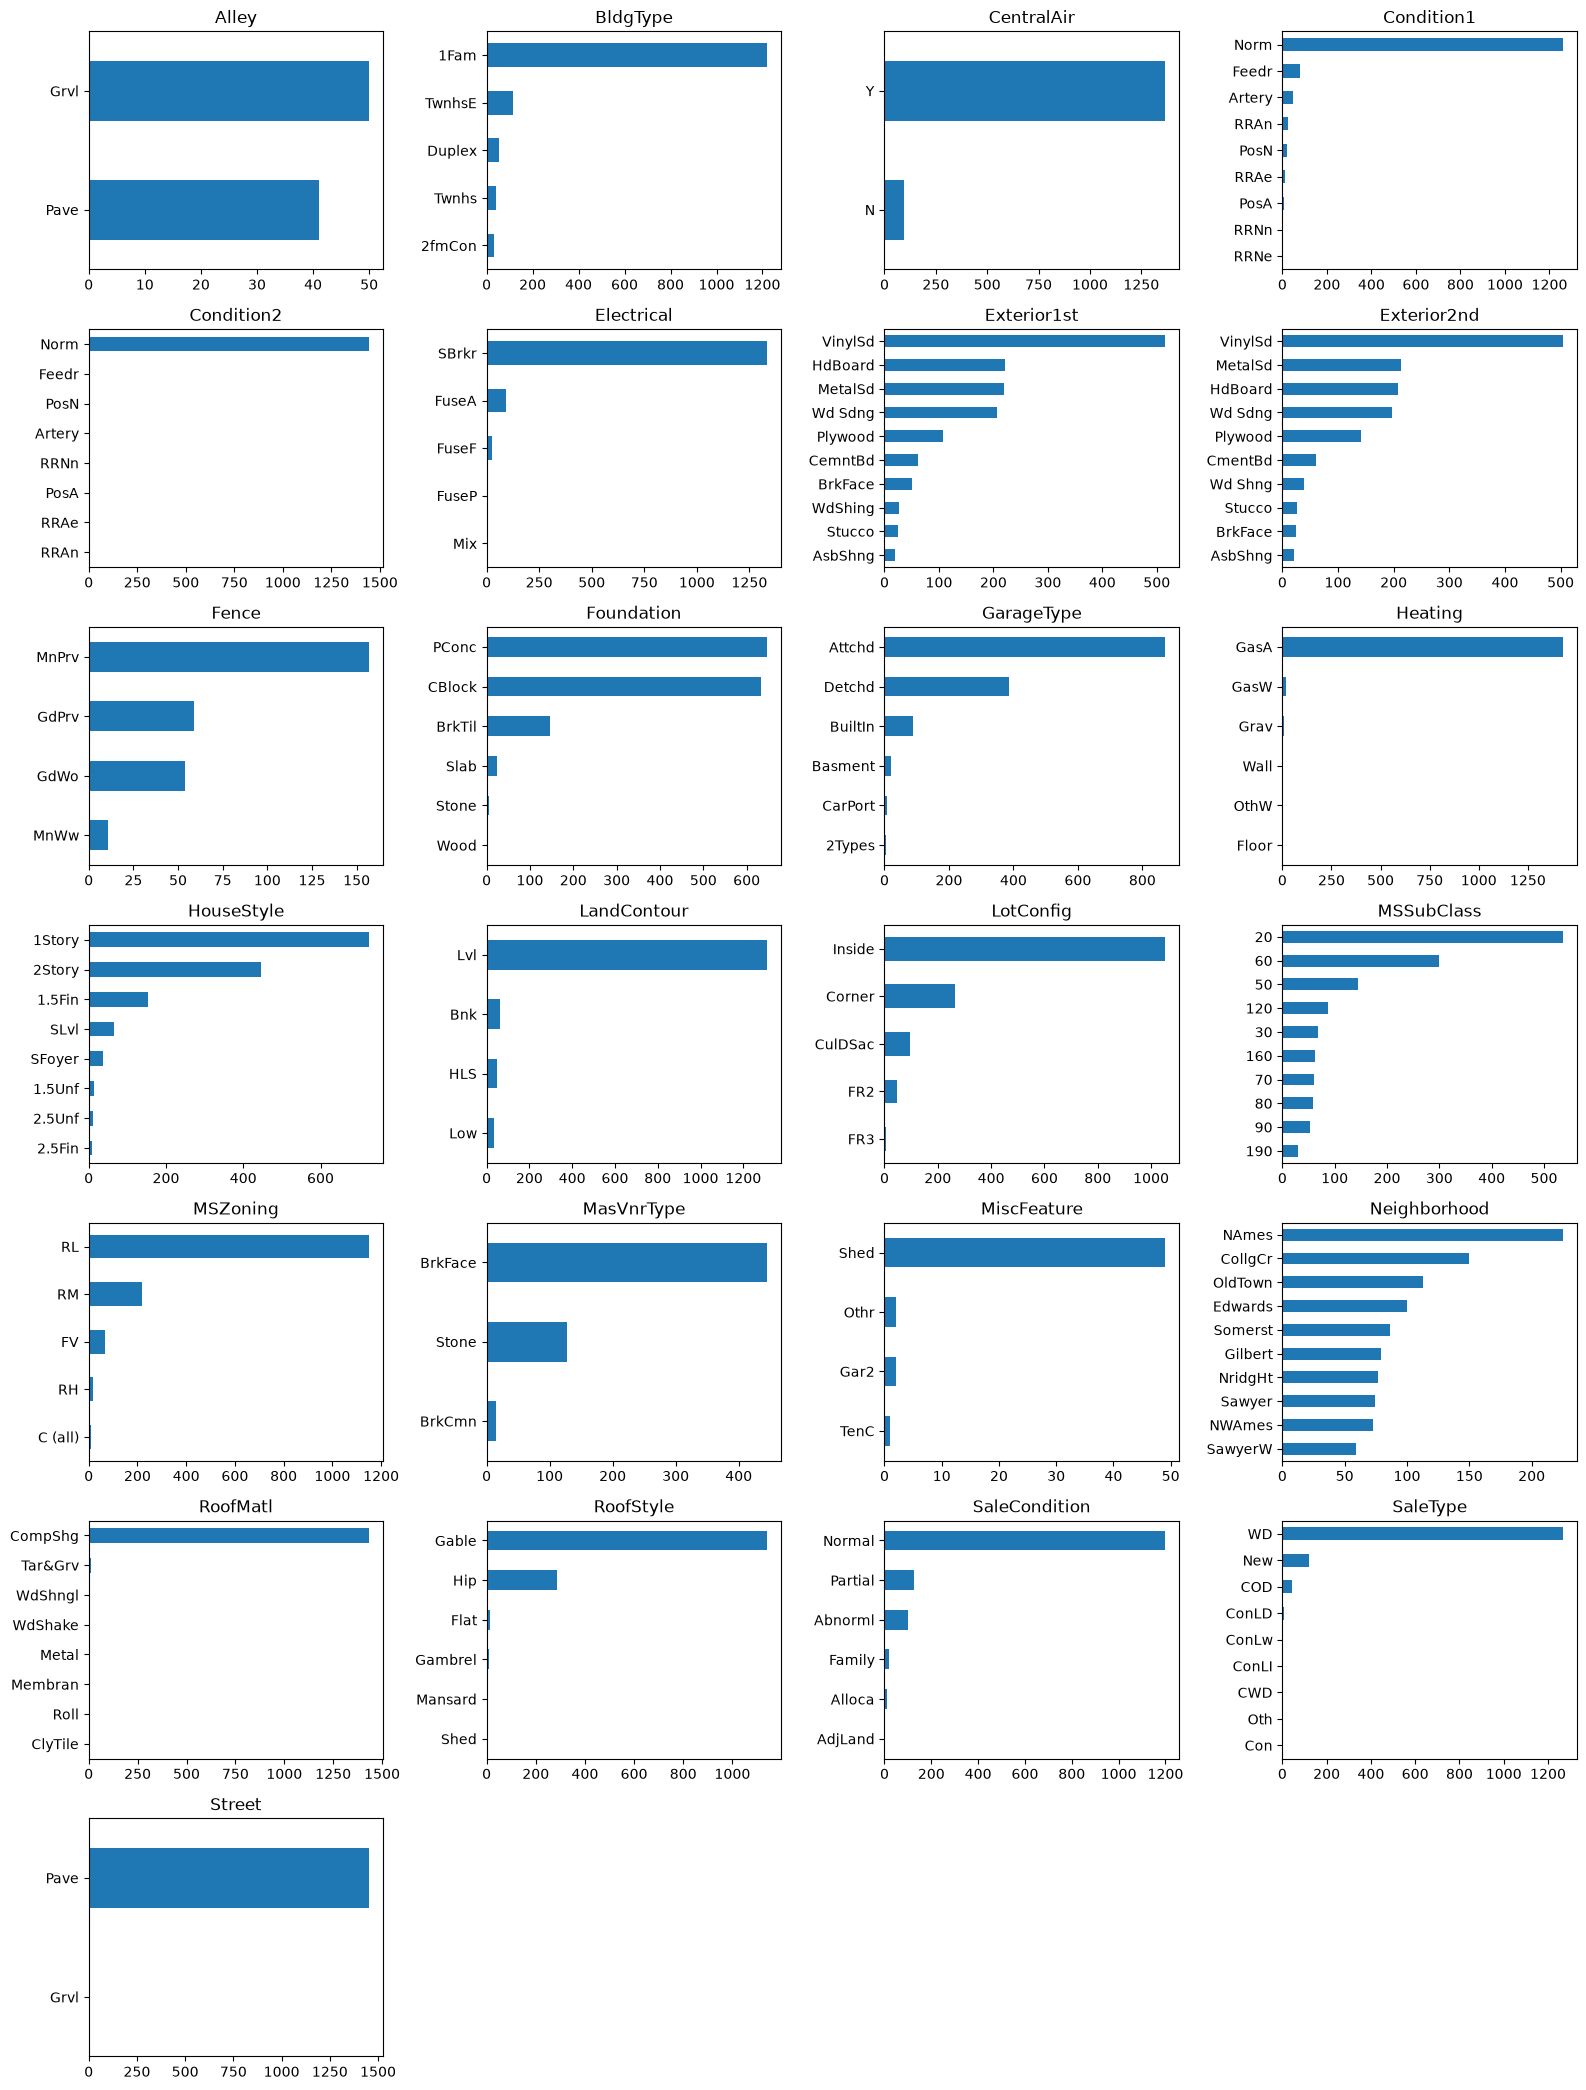

In [73]:
# frequency bar charts — top 10 categories per column (Neighborhood/Exterior*
# have up to 25 levels, so cap at the top 10 to keep each subplot readable).
# horizontal + sorted ascending so the most frequent category reads at the
# top (matplotlib draws barh bottom-up) — vertical labels were unreadable
# for the high-cardinality columns.
TOP_N = 10
n_cols = 4
n_rows = -(-len(NOMINAL_COLS) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))

for ax, col in zip(axes.flat, NOMINAL_COLS):
    top_categories = df_train[col].value_counts().head(TOP_N).sort_values()
    top_categories.plot(kind="barh", ax=ax)
    ax.set_title(col)
    ax.set_ylabel("")

for ax in axes.flat[len(NOMINAL_COLS):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


In [74]:
# rare categories: smallest observed category per nominal column, excluding NaN
RARE_THRESHOLD = 0.01

min_category_pct = {
    col: df_train[col].value_counts(normalize=True, dropna=True).min()
    for col in NOMINAL_COLS
}

nominal_rare = (
    pd.DataFrame.from_dict(min_category_pct, orient="index", columns=["min_category_pct"])
    .sort_values("min_category_pct")
)

flagged_nominal = nominal_rare[nominal_rare["min_category_pct"] < RARE_THRESHOLD]
print(f"{len(flagged_nominal)} of {len(NOMINAL_COLS)} nominal columns have a category under {RARE_THRESHOLD:.0%}:")
flagged_nominal


18 of 25 nominal columns have a category under 1%:


,min_category_pct
Exterior1st,0.000685
Exterior2nd,0.000685
Condition2,0.000685
Heating,0.000685
RoofMatl,0.000685
Electrical,0.000685
Neighborhood,0.001370
Condition1,0.001370
SaleType,0.001370
RoofStyle,0.001370


In [75]:
# summary table
pd.DataFrame({
    "n_levels": df_train[NOMINAL_COLS].nunique(),
    "top_level": df_train[NOMINAL_COLS].apply(lambda s: s.value_counts().index[0]),
    "top_frac": df_train[NOMINAL_COLS].apply(lambda s: s.value_counts(normalize=True).iloc[0]),
    "n_rare_lt10": df_train[NOMINAL_COLS].apply(lambda s: (s.value_counts() < 10).sum()),
    "rare_row_frac": df_train[NOMINAL_COLS].apply(
        lambda s: s.map(s.value_counts()).lt(10).mean()),
    "n_missing": df_train[NOMINAL_COLS].isna().sum(),
}).sort_values("top_frac", ascending=False)

,n_levels,top_level,top_frac,n_rare_lt10,rare_row_frac,n_missing
Street,2,Pave,0.995890,1,0.004110,0
Condition2,8,Norm,0.989726,7,0.010274,0
RoofMatl,8,CompShg,0.982192,6,0.010274,0
Heating,6,GasA,0.978082,4,0.009589,0
CentralAir,2,Y,0.934932,0,0.000000,0
Electrical,5,SBrkr,0.914325,2,0.002740,1
MiscFeature,4,Shed,0.907407,3,0.003425,1406
LandContour,4,Lvl,0.897945,0,0.000000,0
SaleType,9,WD,0.867808,6,0.019178,0
Condition1,9,Norm,0.863014,3,0.010274,0


In [76]:
# category-set alignment: does train/test agree on which categories exist?
# only_train = never seen at test time (missed opportunity, not a risk)
# only_test = model would face a category it never trained on (real risk)
mismatches = {}
for col in NOMINAL_COLS:
    train_levels = set(df_train[col].dropna().unique())
    test_levels = set(df_test[col].dropna().unique())
    only_train = train_levels - test_levels
    only_test = test_levels - train_levels
    if only_train or only_test:
        mismatches[col] = {"only_train": only_train, "only_test": only_test}

for col, diff in mismatches.items():
    print(f"{col}: only_train={sorted(diff['only_train'])} only_test={sorted(diff['only_test'])}")

unseen_in_train = {col: diff["only_test"] for col, diff in mismatches.items() if diff["only_test"]}
print(f"\n{len(mismatches)} of {len(NOMINAL_COLS)} nominal columns have a category-set mismatch;"
      f" {len(unseen_in_train)} have a category that's test-only: {unseen_in_train}")


Condition2: only_train=['RRAe', 'RRAn', 'RRNn'] only_test=[]
Electrical: only_train=['Mix'] only_test=[]
Exterior1st: only_train=['ImStucc', 'Stone'] only_test=[]
Exterior2nd: only_train=['Other'] only_test=[]
Heating: only_train=['Floor', 'OthW'] only_test=[]
HouseStyle: only_train=['2.5Fin'] only_test=[]
MSSubClass: only_train=[] only_test=[np.int64(150)]
MiscFeature: only_train=['TenC'] only_test=[]
RoofMatl: only_train=['ClyTile', 'Membran', 'Metal', 'Roll'] only_test=[]

9 of 25 nominal columns have a category-set mismatch; 1 have a category that's test-only: {'MSSubClass': {np.int64(150)}}


**Decision:**

- Cardinality ranges from 2 (`Street`, `CentralAir`, `Alley`) to 25 (`Neighborhood`), with `Exterior2nd`(16), `Exterior1st`(15), and `MSSubClass`(15) the next highest — all four are one-hot/dummy candidates worth watching for dimensionality once encoded (25 + 16 + 15 + 15 = 71 dummy columns from just 4 features).
- 18 of 25 columns have at least one category under 1% — more than the ordinal section's 13/21, and less surprising here since nominal columns aren't constrained to a small documented scale.
- **Near-constant standouts** (drop-the-column candidates, not merge-the-category): `Street` (99.6% `Pave`), `Condition2` (99.0% `Norm`), `RoofMatl` (98.2% `CompShg`), `Heating` (97.8% `GasA`) — the dominant level leaves almost no variance to work with.
- **Thin-tail-within-a-healthy-column** (bucket-the-rare-categories candidates, e.g. grouping infrequent `Exterior1st` materials into "Other"): `Neighborhood`, `Exterior1st`/`Exterior2nd`, `Condition1`, `RoofStyle`, `SaleType`, `Foundation`.
- **Test-set alignment:** 9 of 25 columns have a category-set mismatch against test, but only one is the dangerous direction — `MSSubClass`'s `150` appears only in test (never seen in train), a genuinely unseen category the model would face at prediction time. The other 8 (`Condition2`, `Electrical`, `Exterior1st`, `Exterior2nd`, `Heating`, `HouseStyle`, `MiscFeature`, `RoofMatl`) are train-only categories — a missed-signal issue, not a prediction-time risk.
- **Boundary held:** flags only — no one-hot encoding, grouping, or dropping applied here. `MSSubClass`'s unseen `150` is the one finding here that genuinely needs a preprocessing decision (e.g. `handle_unknown="ignore"` on a `OneHotEncoder`, or folding it into an existing category); the rest are candidates informed by later steps.


## Test-set verification

Category-set alignment for ordinal and nominal columns already happened
inline in their own sections above (`missing_in_train` and the
`only_train`/`only_test` checks). What's left: do the 28 continuous
numeric columns have the same distribution shape in test as in train, or
does test look different in a way that would undermine conclusions drawn
from train alone?

In [77]:
# train vs. test: is the center in the same place, and is the zero-fraction
# stable? (skew is dropped as the sort key — it's dominated by a handful of
# extreme rows, so it swings hardest on exactly the near-constant columns
# and mostly reflects sample-size noise, not a real shift; kept as a
# secondary column instead)
# n_train/n_test are included because .mean()/.std() silently skip NaN —
# if the two splits have different null counts, comparisons use different
# denominators without anything alerting you to that.
# float(...) around the aggregates: pandas-stubs types .mean()/.std()/
# .skew() as the broad "Scalar" union, and subtracting two of those confuses
# the type checker even though they're plain floats at runtime.
rows = []
for col in CONTINUOUS_NUMERIC_COLS:
    tr, te = df_train[col], df_test[col]
    tr_mean, te_mean = float(tr.mean()), float(te.mean())
    tr_std = float(tr.std())
    tr_zero_frac, te_zero_frac = float((tr == 0).mean()), float((te == 0).mean())
    tr_skew, te_skew = float(tr.skew()), float(te.skew())
    rows.append({
        "column": col,
        "n_train": tr.notna().sum(), "n_test": te.notna().sum(),
        "train_mean": tr_mean, "test_mean": te_mean,
        "train_std": tr_std,
        "mean_shift_std": abs(tr_mean - te_mean) / tr_std,
        "zero_frac_diff": abs(tr_zero_frac - te_zero_frac),
        "skew_diff": abs(tr_skew - te_skew),
    })
dist_compare = pd.DataFrame(rows).set_index("column").sort_values("mean_shift_std", ascending=False)
dist_compare


,n_train,n_test,train_mean,test_mean,train_std,mean_shift_std,zero_frac_diff,skew_diff
column,,,,,,,,
TotRmsAbvGrd,1460,1459,6.517808,6.385195,1.625393,0.081588,0.000000,0.166257
LotArea,1460,1459,10516.828082,9819.161069,9981.264932,0.069898,0.000000,9.092471
LotFrontage,1201,1232,70.049958,68.580357,24.284752,0.060515,0.000000,1.501648
GrLivArea,1460,1459,1515.463699,1486.045922,525.480383,0.055983,0.000000,0.236158
3SsnPorch,1460,1459,3.409589,1.794380,29.317331,0.055094,0.007528,2.219874
Fireplaces,1460,1459,0.613014,0.581220,0.644666,0.049318,0.027740,0.170293
2ndFlrSF,1460,1459,346.992466,325.967786,436.528436,0.048163,0.007243,0.099853
LowQualFinSF,1460,1459,5.844521,3.543523,48.623081,0.047323,0.008213,7.155913
BsmtFinSF2,1460,1458,46.549315,52.619342,161.319273,0.037627,0.009674,0.213916


In [78]:
# mean_shift_std divides by train_std, which is tiny for count-like columns
# (KitchenAbvGr: 0.22, BsmtHalfBath: 0.24) — worth checking those don't
# produce an inflated ratio from a trivial absolute difference before
# trusting the flag. Checked here: both stay under 0.04, so the guard
# doesn't change anything for this dataset, but the check is what matters,
# not the specific result.
MEAN_SHIFT_THRESHOLD = 0.1
ZERO_FRAC_DIFF_THRESHOLD = 0.02

flagged_dist = dist_compare[
    (dist_compare["mean_shift_std"] > MEAN_SHIFT_THRESHOLD)
    | (dist_compare["zero_frac_diff"] > ZERO_FRAC_DIFF_THRESHOLD)
]
print(
    f"{len(flagged_dist)} of {len(CONTINUOUS_NUMERIC_COLS)} columns flagged "
    f"(mean_shift_std > {MEAN_SHIFT_THRESHOLD} or zero_frac_diff > {ZERO_FRAC_DIFF_THRESHOLD}):"
)
flagged_dist


2 of 28 columns flagged (mean_shift_std > 0.1 or zero_frac_diff > 0.02):


,n_train,n_test,train_mean,test_mean,train_std,mean_shift_std,zero_frac_diff,skew_diff
column,,,,,,,,
Fireplaces,1460,1459,0.613014,0.581220,0.644666,0.049318,0.02774,0.170293
EnclosedPorch,1460,1459,21.954110,24.243317,61.119149,0.037455,0.02957,1.579300


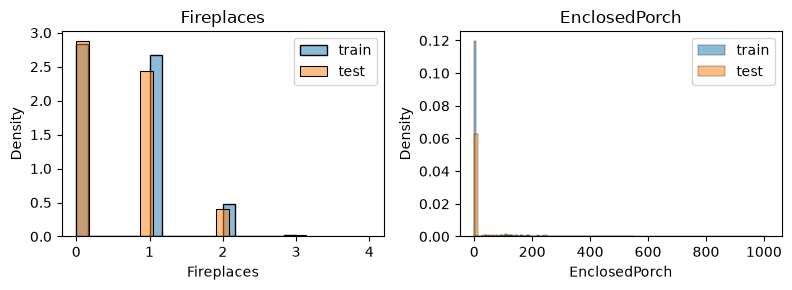

In [79]:
# visual check on the flagged columns: same overall shape, or a real shift?
# density-normalized so the different train/test sample sizes (1460 vs 1459)
# don't distort the comparison
flagged_cols = flagged_dist.index.tolist()
n_cols = 3
n_rows = -(-len(flagged_cols) // n_cols) if flagged_cols else 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False)

for ax, col in zip(axes.flat, flagged_cols):
    sns.histplot(df_train[col], stat="density", color="C0", label="train", alpha=0.5, ax=ax)
    sns.histplot(df_test[col], stat="density", color="C1", label="test", alpha=0.5, ax=ax)
    ax.set_title(col)
    ax.legend()

for ax in axes.flat[len(flagged_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


In [80]:
# quick temporal sanity check: same sale-year window in both splits?
print("YrSold — train:", df_train["YrSold"].min(), "-", df_train["YrSold"].max())
print("YrSold — test: ", df_test["YrSold"].min(), "-", df_test["YrSold"].max())


YrSold — train: 2006 - 2010
YrSold — test:  2006 - 2010


### Adversarial validation

A single number for "are train and test distinguishable at all," rather
than eyeballing 28 columns one at a time: label every train row 0 and
every test row 1, fit a classifier to tell them apart, and cross-validate
the AUC. Near 0.5 means the classifier can't do better than guessing —
train and test look like the same distribution. Meaningfully above ~0.6
means something real shifted, and feature importances say where.

**Scope note:** restricted to `NUMERIC_COLS` here (raw values, no
imputation) — encoding `ORDINAL_COLS`/`NOMINAL_COLS` is preprocessing's
job, out of scope for this notebook, so they're left out of this
diagnostic rather than hastily encoded just to feed a classifier.
`HistGradientBoostingClassifier` handles the remaining NaNs natively, no
imputation needed for this to run.

In [81]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

X_adv = pd.concat([df_train[NUMERIC_COLS], df_test[NUMERIC_COLS]], ignore_index=True)
y_adv = np.concatenate([np.zeros(len(df_train)), np.ones(len(df_test))])

# shuffle=True matters here — the CSV rows aren't randomly ordered, so an
# unshuffled StratifiedKFold draws each fold from a narrow contiguous slice
# of both files and reports a misleadingly bad score (checked: ~0.22 AUC
# unshuffled vs. ~0.50 shuffled, on the exact same data and classifier)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
clf = HistGradientBoostingClassifier(random_state=0)
adv_scores = cross_val_score(clf, X_adv, y_adv, cv=cv, scoring="roc_auc")
print("CV AUC per fold:", adv_scores.round(3))
print("mean AUC:", adv_scores.mean().round(3))


CV AUC per fold: [0.494 0.553 0.486 0.481 0.472]
mean AUC: 0.497


**Decision:**

- **Point taken on the decode-first concern — checked, and it doesn't apply here.** This notebook (per its scope note) hasn't run any NA→None/0 decode on either split — `GarageArea`/`BsmtFinSF*` etc. are being compared as raw CSV values throughout, so there's no train-only fillna to have missed. Worth remembering once a preprocessing notebook does add that step: re-run this comparison after, not just before.
- **Non-null counts (`n_train`/`n_test`) now shown directly in `dist_compare`.** Most columns match exactly (1460/1459); `LotFrontage` (1201/1232) and `MasVnrArea` (1452/1444) differ, consistent with [2_missingness.ipynb](2_missingness.ipynb)'s known missingness rates in both splits — not a new finding, but now visible in this table rather than assumed.
- **Re-sorting by `mean_shift_std` instead of `skew_diff` changes the picture completely.** Nothing crosses either threshold — max `mean_shift_std` is `TotRmsAbvGrd` at 0.082, max `zero_frac_diff` is `EnclosedPorch` at 0.030. The previous skew-sorted version was flagging `LotArea`/`PoolArea`/`MiscVal`/`3SsnPorch` — exactly the near-constant columns where a couple of extreme rows landing on one side of the split swings skew by double digits with no practical consequence, as predicted.
- **`train_std` guard checked, doesn't change anything here.** The smallest-std columns (`KitchenAbvGr` 0.22, `BsmtHalfBath` 0.24) still show tiny `mean_shift_std` (0.019, 0.032) — no inflated ratio from a trivial absolute difference, but worth checking rather than assuming on any future dataset.
- **Adversarial validation confirms it directly: mean CV AUC ≈ 0.50** (shuffled `StratifiedKFold`, `HistGradientBoostingClassifier` on `NUMERIC_COLS`) — train and test are indistinguishable to a model that's actually trying. Matches expectation for a random split over the same Ames records.
- **Lesson worth keeping:** the unshuffled version of the same CV scored ≈0.22 — badly *below* chance, not near it — because the raw CSV row order isn't random and an unshuffled `StratifiedKFold` draws each fold from a narrow contiguous slice of it. Same data, same classifier, wrong conclusion without the shuffle.
- **Boundary held:** verification only, no correction applied. Revised conclusion from the numeric section still stands, now on firmer footing: the skew/zero-heavy flags found there generalize to test — not because the diagnostics agreed by coincidence, but because a proper adversarial check confirms no shift at all.

## Summary

| Section | Columns | Flagged | Key finding |
|---|---|---|---|
| Numeric | 33 (28 continuous + 5 temporal) | 21 skewed/zero-heavy (75%) | Presence/absence group (14 cols, extreme skew from a mostly-absent amenity) vs. right-skewed-size group (7 cols, ordinary log/Box-Cox candidates); temporal columns show expected shapes, no anomalies |
| Ordinal | 21 | 13 lopsided at <1% (62%); 8 documented levels absent from train | Every observed level matches `data_description.txt`'s order, no contradictions; the 8 absent-from-train levels are absent from test too, not a train-only gap |
| Nominal | 25 | 18 with a rare category <1% (72%); 9 train/test category-set mismatches | Cardinality 2–25; only 1 of the 9 mismatches is the risky direction — `MSSubClass`'s `150` appears in test but never in train |
| Test-set verification | 28 continuous (+ adversarial validation on all 33 `NUMERIC_COLS`) | 0 meaningful shift | Mean CV AUC ≈ 0.497 (shuffled `StratifiedKFold`, `HistGradientBoostingClassifier`) — train and test are statistically indistinguishable |

**Candidates carried forward to preprocessing:**

- **Drop candidates** (near-zero variance): `Utilities`, `Street`, `Condition2`, `RoofMatl`, `Heating` — 5 columns where one level accounts for 97–99.9% of rows, leaving almost nothing for a model to learn from.
- **Transform candidates** (numeric, 21 columns): a has-X flag plus a transform on the nonzero subset for the 14 presence/absence columns; a plain log/Box-Cox for the 7 right-skewed-size columns.
- **Bucket candidates** (rare-level grouping): 12 ordinal columns (thin `Po`/`Ex` tails on an otherwise healthy quality scale) and 6 nominal columns (`Neighborhood`, `Exterior1st`/`Exterior2nd`, `Condition1`, `RoofStyle`, `SaleType`, `Foundation`) with a thin tail inside an otherwise well-spread distribution.
- **Unseen-category handling**: `MSSubClass`'s `150` needs an explicit strategy (e.g. `OneHotEncoder(handle_unknown="ignore")`, or folding it into a neighboring category) since no training row ever showed it.

**Boundary held throughout:** every flag above is informational — no transform, encoding, merge, or drop was applied in this notebook, consistent with [2_missingness.ipynb](2_missingness.ipynb)'s study-only precedent. These candidate lists are a starting point for preprocessing, not a final decision — the bivariate step still ahead (how each of these relates to `SalePrice`) is what should actually decide which candidates are worth acting on.